In [1]:
import numpy as np
from bigfile import BigFile
import matplotlib.pyplot as plt
from profile_funcs import *

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-xhx8xunp because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [ ]:
# indices for z = 0, 0.2, 0.5, 1.0 
z_list = [0.0, 0.2, 0.5, 1.0]
idx_kn1DF = [21, 18, 15, 13]
idx_kn1R1 = [21, 17, 15, 13]
idx_kn0R1 = [21, 18, 15, 13]
idx_dmo = [19, 16, 14, 12]
idx_kn1SR1 = [20, 17, 15, 13]
idx_kn1SDF = [20, 17, 14, 12]

In [3]:
# load pigs
dir_parent = '/scratch3/01317/yyang440/small_subfind'
pigs_kn1DF = [BigFile(f'{dir_parent}/kn1-DF/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1DF]
pigs_kn1R1 = [BigFile(f'{dir_parent}/kn1-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1R1]
pigs_kn0R1 = [BigFile(f'{dir_parent}/kn0-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn0R1]
pigs_dmo    = [BigFile(f'{dir_parent}/dmo/{i:03d}/PIG_{i:03d}_subfind') for i in idx_dmo]
pigs_kn1SR1 = [BigFile(f'{dir_parent}/kn1S-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1SR1]
pigs_kn1SDF = [BigFile(f'{dir_parent}/kn1S-DF/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1SDF]

labels_sim = ['Kn1-DF', 'Kn1-Repos1', 'Kn0-Repos1', 'DMO', 'Kn1S-Repos1', 'Kn1S-DF']


In [4]:
# only consider z = 0 for now
idx_z = 0

# r_kn1DF, rho_kn1DF = get_rho_profile(pigs_kn1DF[idx_z])
# r_kn1R1, rho_kn1R1 = get_rho_profile(pigs_kn1R1[idx_z])
# r_kn0R1, rho_kn0R1 = get_rho_profile(pigs_kn0R1[idx_z])
# r_dmo,    rho_dmo    = get_rho_profile(pigs_dmo[idx_z])
# r_kn1SR1, rho_kn1SR1 = get_rho_profile(pigs_kn1SR1[idx_z])
# r_kn1SDF, rho_kn1SDF = get_rho_profile(pigs_kn1SDF[idx_z])

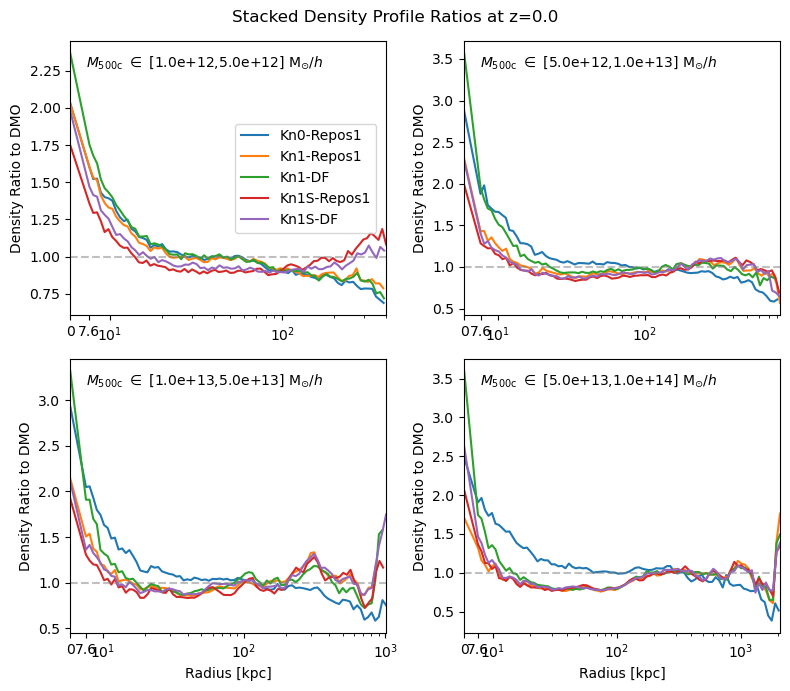

In [6]:
from matplotlib.ticker import SymmetricalLogLocator, LogLocator, NullFormatter

# figure of density profile ratio, 2x2 panels, for mass ranges 1e12-5e12, 5e12-1e13, 1e13-5e13, 5e13-1e14 Msun/h

m_ranges = [(1e12, 5e12), (5e12, 1e13), (1e13, 5e13), (5e13, 1e14)]

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# flatten axes for easy iteration
axes = axes.flatten()

for i, (m_lower, m_upper) in enumerate(m_ranges):

    # stacked density profiles
    
    r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1 = get_stacked_rho_profile(pigs_kn0R1[idx_z], m_lower, m_upper)
    r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1 = get_stacked_rho_profile(pigs_kn1R1[idx_z], m_lower, m_upper)
    r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF = get_stacked_rho_profile(pigs_kn1DF[idx_z], m_lower, m_upper)
    r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo = get_stacked_rho_profile(pigs_dmo[idx_z], m_lower, m_upper)
    r_kn1SR1, rho_kn1SR1, rho_p16_kn1SR1, rho_p84_kn1SR1 = get_stacked_rho_profile(pigs_kn1SR1[idx_z], m_lower, m_upper)
    r_kn1SDF, rho_kn1SDF, rho_p16_kn1SDF, rho_p84_kn1SDF = get_stacked_rho_profile(pigs_kn1SDF[idx_z], m_lower, m_upper)

    # ratio of hydro to DMO
    r_common_kn0R1, ratio_kn0R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn0R1, rho_kn0R1)
    axes[i].plot(r_common_kn0R1, ratio_kn0R1, label='Kn0-Repos1')
    r_common_kn1R1, ratio_kn1R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1R1, rho_kn1R1)
    axes[i].plot(r_common_kn1R1, ratio_kn1R1, label='Kn1-Repos1')
    r_common_kn1DF, ratio_kn1DF = get_profile_ratio(r_dmo, rho_dmo, r_kn1DF, rho_kn1DF)
    axes[i].plot(r_common_kn1DF, ratio_kn1DF, label='Kn1-DF')
    r_common_kn1SR1, ratio_kn1SR1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1SR1, rho_kn1SR1)
    axes[i].plot(r_common_kn1SR1, ratio_kn1SR1, label='Kn1S-Repos1')

    r_common_kn1SDF, ratio_kn1SDF = get_profile_ratio(r_dmo, rho_dmo, r_kn1SDF, rho_kn1SDF)
    axes[i].plot(r_common_kn1SDF, ratio_kn1SDF, label='Kn1S-DF')
    
    # horizontal line at y=1
    axes[i].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    

    axes[i].set_ylabel('Density Ratio to DMO')

    # annotate mass range using text
    axes[i].text(0.05, 0.95, r'$M_\mathrm{500c}$ $\in$ [%.1e,%.1e] M$_{\odot}/h$' % (m_lower, m_upper), transform=axes[i].transAxes, 
                 verticalalignment='top') 
    # x lower limit as the minimum non-zero r_common among all sims
    r_min_nz = min([r_common_kn0R1[r_common_kn0R1>0].min(), r_common_kn1R1[r_common_kn1R1>0].min(),
                    r_common_kn1DF[r_common_kn1DF>0].min(), r_common_kn1SR1[r_common_kn1SR1>0].min(),
                    r_common_kn1SDF[r_common_kn1SDF>0].min()])
    # x upper limit maximum r
    r_max = max([r_common_kn0R1.max(), r_common_kn1R1.max(),
                    r_common_kn1DF.max(), r_common_kn1SR1.max(),
                    r_common_kn1SDF.max()])

    
    axes[i].set_xscale('symlog', linthresh=r_min_nz, linscale=0.1)
    # x ticks
    axes[i].set_xticks([0, r_min_nz, 1e1, 1e2, 1e3],[0, '%.1f' % r_min_nz, r'$10^1$', r'$10^2$', r'$10^3$'])
    # show minor ticks
    # axes[i].minorticks_on()
    # ticks = axes[i].xaxis.get_minor_locator().tick_values(r_min_nz, r_max)
    # ticks = ticks[(ticks >= 10) & (ticks <= r_max)]
    # axes[i].set_xticks(ticks, minor=True)
    # axes[i].xaxis.set_minor_locator(
    #     LogLocator(base=10.0, linthresh=r_min_nz, subs=np.arange(2, 10) * 0.1)
    # )
    # axes[i].xaxis.set_minor_locator(
    # SymmetricalLogLocator(
    #     base=10,
    #     linthresh=r_min_nz,
    #     subs=np.arange(2, 10)
    #     )
    # )
    # axes[i].xaxis.set_minor_formatter(NullFormatter())
    # 1. Define the minor tick values between 10 and 10000
    # This creates [20, 30...90] and [200, 300...900]
    minor_ticks = np.concatenate([np.arange(2, 10) * 10, 
                                 np.arange(2, 10) * 100, 
                                 np.arange(2, 10) * 1000])
    
    # 2. Apply them to the x-axis
    axes[i].set_xticks(minor_ticks, minor=True)
    
    # 3. Ensure they don't have labels (standard for minor ticks)
    axes[i].xaxis.set_minor_formatter(NullFormatter())
    axes[i].set_xlim(0, r_max)

# x label only for bottom panels
for i in [2, 3]:
    axes[i].set_xlabel('Radius [kpc]')

# legend only for the first panel
axes[0].legend(loc='center left', bbox_to_anchor=(.5, 0.5))

plt.suptitle(f'Stacked Density Profile Ratios at z={z_list[idx_z]}')
plt.tight_layout()
plt.show()

In [ ]:
# z = 1
idx_z = 3
# figure of density profile ratio, 2x2 panels, for mass ranges 1e12-5e12, 5e12-1e13, 1e13-5e13, 5e13-1e14 Msun/h

m_ranges = [(1e12, 5e12), (5e12, 1e13), (1e13, 5e13), (5e13, 1e14)]

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# flatten axes for easy iteration
axes = axes.flatten()

for i, (m_lower, m_upper) in enumerate(m_ranges):

    # stacked density profiles
    
    r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1 = get_stacked_rho_profile(pigs_kn0R1[idx_z], m_lower, m_upper)
    r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1 = get_stacked_rho_profile(pigs_kn1R1[idx_z], m_lower, m_upper)
    r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF = get_stacked_rho_profile(pigs_kn1DF[idx_z], m_lower, m_upper)
    r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo = get_stacked_rho_profile(pigs_dmo[idx_z], m_lower, m_upper)
    r_kn1SR1, rho_kn1SR1, rho_p16_kn1SR1, rho_p84_kn1SR1 = get_stacked_rho_profile(pigs_kn1SR1[idx_z], m_lower, m_upper)
    r_kn1SDF, rho_kn1SDF, rho_p16_kn1SDF, rho_p84_kn1SDF = get_stacked_rho_profile(pigs_kn1SDF[idx_z], m_lower, m_upper)

    # ratio of hydro to DMO
    r_common_kn0R1, ratio_kn0R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn0R1, rho_kn0R1)
    axes[i].plot(r_common_kn0R1, ratio_kn0R1, label='Kn0-Repos1')
    r_common_kn1R1, ratio_kn1R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1R1, rho_kn1R1)
    axes[i].plot(r_common_kn1R1, ratio_kn1R1, label='Kn1-Repos1')
    r_common_kn1DF, ratio_kn1DF = get_profile_ratio(r_dmo, rho_dmo, r_kn1DF, rho_kn1DF)
    axes[i].plot(r_common_kn1DF, ratio_kn1DF, label='Kn1-DF')
    r_common_kn1SR1, ratio_kn1SR1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1SR1, rho_kn1SR1)
    axes[i].plot(r_common_kn1SR1, ratio_kn1SR1, label='Kn1S-Repos1')

    r_common_kn1SDF, ratio_kn1SDF = get_profile_ratio(r_dmo, rho_dmo, r_kn1SDF, rho_kn1SDF)
    axes[i].plot(r_common_kn1SDF, ratio_kn1SDF, label='Kn1S-DF')
    
    # horizontal line at y=1
    axes[i].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    

    axes[i].set_ylabel('Density Ratio to DMO')

    # annotate mass range using text
    axes[i].text(0.05, 0.95, r'$M_\mathrm{500c}$ $\in$ [%.1e,%.1e] M$_{\odot}/h$' % (m_lower, m_upper), transform=axes[i].transAxes, 
                 verticalalignment='top') 
    # x lower limit as the minimum non-zero r_common among all sims
    r_min_nz = min([r_common_kn0R1[r_common_kn0R1>0].min(), r_common_kn1R1[r_common_kn1R1>0].min(),
                    r_common_kn1DF[r_common_kn1DF>0].min(), r_common_kn1SR1[r_common_kn1SR1>0].min(),
                    r_common_kn1SDF[r_common_kn1SDF>0].min()])
    # x upper limit maximum r
    r_max = max([r_common_kn0R1.max(), r_common_kn1R1.max(),
                    r_common_kn1DF.max(), r_common_kn1SR1.max(),
                    r_common_kn1SDF.max()])

    
    axes[i].set_xscale('symlog', linthresh=r_min_nz, linscale=0.1)
    # x ticks
    axes[i].set_xticks([0, r_min_nz, 1e1, 1e2, 1e3],[0, '%.1f' % r_min_nz, r'$10^1$', r'$10^2$', r'$10^3$'])
    # show minor ticks
    # axes[i].minorticks_on()
    # ticks = axes[i].xaxis.get_minor_locator().tick_values(r_min_nz, r_max)
    # ticks = ticks[(ticks >= 10) & (ticks <= r_max)]
    # axes[i].set_xticks(ticks, minor=True)
    # axes[i].xaxis.set_minor_locator(
    #     LogLocator(base=10.0, linthresh=r_min_nz, subs=np.arange(2, 10) * 0.1)
    # )
    # axes[i].xaxis.set_minor_locator(
    # SymmetricalLogLocator(
    #     base=10,
    #     linthresh=r_min_nz,
    #     subs=np.arange(2, 10)
    #     )
    # )
    # axes[i].xaxis.set_minor_formatter(NullFormatter())
    # 1. Define the minor tick values between 10 and 10000
    # This creates [20, 30...90] and [200, 300...900]
    minor_ticks = np.concatenate([np.arange(2, 10) * 10, 
                                 np.arange(2, 10) * 100, 
                                 np.arange(2, 10) * 1000])
    
    # 2. Apply them to the x-axis
    axes[i].set_xticks(minor_ticks, minor=True)
    
    # 3. Ensure they don't have labels (standard for minor ticks)
    axes[i].xaxis.set_minor_formatter(NullFormatter())
    axes[i].set_xlim(0, r_max)

# x label only for bottom panels
for i in [2, 3]:
    axes[i].set_xlabel('Radius [kpc]')

# legend only for the first panel
axes[0].legend(loc='center left', bbox_to_anchor=(.5, 0.5))

plt.suptitle(f'Stacked Density Profile Ratios at z={z_list[idx_z]}')
plt.tight_layout()
plt.show()

In [ ]:
# plot for z = 0 and z = 1: 2 rows, 3 columns for mass ranges 1e11-1e12, 1e12-1e13, 1e13-1e14 Msun/h